### Фильтры

### Рамки


In [ ]:
import cv2
import numpy as np

# Загрузка изображения
cv2.namedWindow("image")
image = cv2.imread('gradient.png',cv2.IMREAD_REDUCED_COLOR_4)
cv2.imshow("image", image)
# Задаем толщину рамки для всех сторон
top, bottom, left, right = [30, 30, 30, 30]

# Создаем рамку для каждого из типов
borderType = [cv2.BORDER_CONSTANT, cv2.BORDER_REFLECT, cv2.BORDER_REFLECT_101, cv2.BORDER_REPLICATE, cv2.BORDER_WRAP]
borderName = ['CONSTANT', 'REFLECT', 'REFLECT_101', 'REPLICATE', 'WRAP']

for i, btype in enumerate(borderType):
    bordered_image = cv2.copyMakeBorder(image, top, bottom, left, right, btype, value=[255, 0, 255])
    cv2.imshow(borderName[i], bordered_image)

cv2.waitKey(0)
cv2.destroyAllWindows()

### Размытие

In [ ]:
import cv2
# Загрузка изображения
image = cv2.imread('2-1.jpg',cv2.IMREAD_REDUCED_COLOR_4) 
# Применение boxFilter 
boxFilteredImageN = cv2.boxFilter(image, -1, (11, 11), normalize=True)
blurredImage = cv2.blur(image, (11, 11))
cv2.waitKey(0)
cv2.destroyAllWindows()
# Отображение оригинального и обработанных изображений
cv2.imshow('Original', image)
cv2.imshow('Blurred', blurredImage)
cv2.imshow('Box Filtered (Normalize)', boxFilteredImageN)
cv2.waitKey(0)
cv2.destroyAllWindows()




In [ ]:
cv2.imshow('Original', image)
boxFilteredImage = cv2.boxFilter(image, -1, (11, 11), normalize=False)
boxFilteredImageN = cv2.boxFilter(image, -1, (11, 11), normalize=True)
cv2.imshow('Box Filtered (Normalize)', boxFilteredImageN)
cv2.imshow('Box Filtered (No Normalize)', boxFilteredImage)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [15]:
cv2.imshow('Original', image)
boxFilteredImagehoriz = cv2.boxFilter(image, -1, (50, 5), normalize=True)
boxFilteredImageVert = cv2.boxFilter(image, -1, (5, 50), normalize=True)
cv2.imshow('Box Filtered Vert', boxFilteredImageVert)
cv2.imshow('Box Filtered Horiz', boxFilteredImagehoriz)
cv2.waitKey(0)
cv2.destroyAllWindows()

### Фильтр Гаусса

In [16]:

# Применение Гауссова фильтра
gaussianBlurred = cv2.GaussianBlur(image, (9, 9), 0)
# Отображение оригинального и размытого изображений
cv2.imshow('Original', image)
cv2.imshow('Gaussian Blurred', gaussianBlurred)
cv2.waitKey(0)
cv2.destroyAllWindows()


In [21]:
import numpy as np

def generate_gaussian_kernel(kernel_size, sigma):
    ax = np.arange(-kernel_size // 2 + 1., kernel_size // 2 + 1.)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.round(np.exp(-(xx**2 + yy**2) / (2. * sigma**2)),3)
    # kernel = kernel / np.sum(kernel)
    return kernel
kernel_size = 3  
sigma = 0.5     
gaussian_kernel = generate_gaussian_kernel(kernel_size, sigma)
print(gaussian_kernel)


[[0.018 0.135 0.018]
 [0.135 1.    0.135]
 [0.018 0.135 0.018]]


### Простое пороговое преобразование

In [24]:


# Загрузка изображения в градациях серого
image = cv2.imread('gradient.png', cv2.IMREAD_REDUCED_GRAYSCALE_4)

# Определение порога
threshold_value = 150

# Бинарное пороговое преобразование
_, binary = cv2.threshold(image, threshold_value, 255, cv2.THRESH_BINARY)

# Инвертированное бинарное пороговое преобразование
_, binary_inv = cv2.threshold(image, threshold_value, 255, cv2.THRESH_BINARY_INV)

# Пороговое преобразование с усечением
_, trunc = cv2.threshold(image, threshold_value, 255, cv2.THRESH_TRUNC)

# Пороговое преобразование до нуля
_, tozero = cv2.threshold(image, threshold_value, 255, cv2.THRESH_TOZERO)

# Инвертированное пороговое преобразование до нуля
_, tozero_inv = cv2.threshold(image, threshold_value, 255, cv2.THRESH_TOZERO_INV)

# Отображение результатов
cv2.imshow('Original', image)
cv2.imshow('Binary', binary)
cv2.imshow('Binary Inverted', binary_inv)
cv2.imshow('Truncate', trunc)
cv2.imshow('To Zero', tozero)
cv2.imshow('To Zero Inverted', tozero_inv)

cv2.waitKey(0)
cv2.destroyAllWindows()

###  Автоматическое пороговое преобраование

In [28]:
# Загрузка изображения в градациях серого
image = cv2.imread('theresh.png', cv2.IMREAD_REDUCED_GRAYSCALE_4)
# метод Отсу
tr1, otsu = cv2.threshold(image, threshold_value, 255, cv2.THRESH_OTSU)
# Метод треугольника
tr2, triangle = cv2.threshold(image, threshold_value, 255, cv2.THRESH_TRIANGLE)


print(tr1)
print(tr2)
# Отображение результатов
cv2.imshow('Original', image)
cv2.imshow('otsu', otsu)
cv2.imshow('triangle', triangle)
cv2.waitKey(0)
cv2.destroyAllWindows()

93.0
25.0


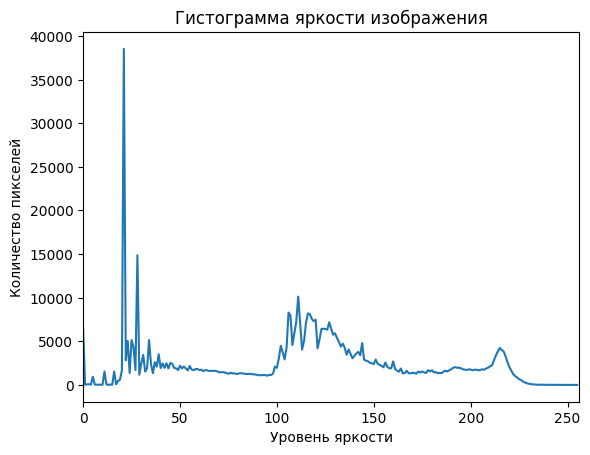

In [29]:
import cv2
from matplotlib import pyplot as plt

# Загрузите изображение в градациях серого
image = cv2.imread('theresh.png', cv2.IMREAD_REDUCED_GRAYSCALE_4)
histogram = cv2.calcHist([image], [0], None, [256], [0, 256])
# Отобразите гистограмму
plt.figure()
plt.title("Гистограмма яркости изображения")
plt.xlabel("Уровень яркости")
plt.ylabel("Количество пикселей")
plt.plot(histogram)
plt.xlim([0, 256])
plt.show()

### Адаптивное пороговое преобразование

In [30]:
# Загрузка изображения в градациях серого
image = cv2.imread('theresh.png', cv2.IMREAD_REDUCED_GRAYSCALE_4)

# Применение адаптивного порогового преобразования
adaptive_thresh = cv2.adaptiveThreshold(image, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                                        cv2.THRESH_BINARY, 9, 15)
tr1, otsu = cv2.threshold(image, threshold_value, 255, cv2.THRESH_OTSU)
# Метод треугольника
tr2, triangle = cv2.threshold(image, threshold_value, 255, cv2.THRESH_TRIANGLE)
# Отображение результата
cv2.imshow('Adaptive Threshold', adaptive_thresh)
cv2.imshow('otsu', otsu)
cv2.imshow('triangle', triangle)
cv2.imshow('Original', image)
cv2.waitKey(0)
cv2.destroyAllWindows()

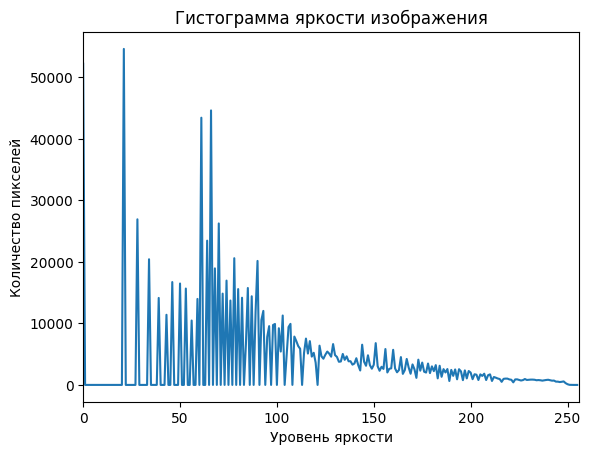

In [11]:
import cv2
from matplotlib import pyplot as plt

# Загрузите изображение в градациях серого

image = cv2.imread('theresh2.png', cv2.IMREAD_GRAYSCALE)
histogram = cv2.calcHist([image], [0], None, [256], [0, 256])
# Отобразите гистограмму
plt.figure()
plt.title("Гистограмма яркости изображения")
plt.xlabel("Уровень яркости")
plt.ylabel("Количество пикселей")
plt.plot(histogram)
plt.xlim([0, 256])
plt.show()

In [13]:
image = cv2.imread('2-1.jpg', cv2.IMREAD_GRAYSCALE)
adaptive_thresh = cv2.adaptiveThreshold(image, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                                        cv2.THRESH_BINARY, 9, 15)
tr1, otsu = cv2.threshold(image, threshold_value, 255, cv2.THRESH_OTSU)
# Метод треугольника
tr2, triangle = cv2.threshold(image, threshold_value, 255, cv2.THRESH_TRIANGLE)
# Отображение результата

cv2.imshow('otsu', otsu)

cv2.waitKey(0)
cv2.destroyAllWindows()

In [35]:
image = cv2.imread('2-2.jpg', cv2.IMREAD_REDUCED_GRAYSCALE_4)
adaptive_thresh = cv2.adaptiveThreshold(image, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                                        cv2.THRESH_BINARY, 55, 0)
tr1, theresh = cv2.threshold(image, 175, 255, cv2.THRESH_BINARY)
# Метод треугольника
tr2, triangle = cv2.threshold(image, threshold_value, 255, cv2.THRESH_TRIANGLE)
# Отображение результата
# cv2.imshow('Adaptive Threshold', adaptive_thresh)
cv2.imshow('result', theresh)
# cv2.imshow('triangle', triangle)
cv2.imshow('Original', image)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [38]:
# Загрузка изображения в градациях серого
image = cv2.imread('2-3.png', cv2.IMREAD_REDUCED_GRAYSCALE_2)

# Применение адаптивного порогового преобразования
adaptive_thresh = cv2.adaptiveThreshold(image, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                                        cv2.THRESH_BINARY, 9, 15)
tr1, otsu = cv2.threshold(image, threshold_value, 255, cv2.THRESH_OTSU)
# Метод треугольника
tr2, triangle = cv2.threshold(image, threshold_value, 255, cv2.THRESH_TRIANGLE)
# Отображение результата
cv2.imshow('Adaptive Threshold', adaptive_thresh)
# cv2.imshow('otsu', otsu)
# cv2.imshow('triangle', triangle)
cv2.imshow('Original', image)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [61]:
# Загрузка изображения в градациях серого
image = cv2.imread('theresh.png', cv2.IMREAD_GRAYSCALE)


tr1, otsu = cv2.threshold(image, threshold_value, 255, cv2.THRESH_OTSU)
# Метод треугольника
print(tr1)
tr2, triangle = cv2.threshold(image, threshold_value, 255, cv2.THRESH_TRIANGLE)
tr2, triangle = cv2.threshold(image, 170, 255, cv2.THRESH_BINARY)
# Отображение результата
# cv2.imshow('Adaptive Threshold', adaptive_thresh)
cv2.imshow('result1', otsu)
cv2.imshow('result2', triangle)
cv2.imshow('Original', image)
cv2.waitKey(0)
cv2.destroyAllWindows()

129.0
